In [1]:
print("import libraries")
print("...")
#to disable notebook warnings
import warnings
warnings.filterwarnings('ignore')

# data processing
import pandas as pd

# linear algebra
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# data standardization
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# train test split
from sklearn.model_selection import train_test_split

# ML
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR

## pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

## metrics
from sklearn.metrics import mean_absolute_error, r2_score

print("...")
print("Done")
print("Libraries imported")

import libraries
...
...
Done
Libraries imported


In [2]:
### Reading data

def read_data(path):
    data = pd.read_csv(path)
    return data

def drop_columns(data, columns):
    data.drop(columns=columns, axis=1, inplace=True)

train_data = read_data('/agri_yield_forecast/data/agricultural_yield_train.csv')
test_data = read_data('/agri_yield_forecast/data/agricultural_yield_test.csv')

### dropping id column 

#drop_columns(train_data, 'id')
#drop_columns(test_data, 'id')

train_data.head()

,Soil_Quality,Seed_Variety,Fertilizer_Amount_kg_per_hectare,Sunny_Days,Rainfall_mm,Irrigation_Schedule,Yield_kg_per_hectare
0,96.415657,1,147.853040,94.593926,444.267569,3,683.759119
1,92.352626,0,281.565396,90.504644,517.585491,7,678.714861
2,63.714785,1,137.864940,97.329340,420.310945,8,934.691975
3,90.084256,1,100.946659,113.404828,547.817646,7,905.842541
4,81.600341,1,223.088908,83.048176,434.726333,6,897.584665


In [3]:
def analyze_data(data):
    
    print("DataFrame Info:")
    print("=================================")
    display(data.info())
    print("\n")
    
    print("DataFrame Values:")
    print("=================================")
    display(data.head())
    print("\n")
    
    print("DataFrame Desscription")
    print("=================================")
    display(data.describe())
    print("\n")
    
    print("Number of null values")
    print("=================================")
    display(data.isnull().sum())
    print("\n")
    
    print("Number of duplicated values")
    print("==================================")
    display(data.duplicated().sum())
    print("\n")
    
    print("Number of unique values")
    print("==================================")
    display(data.nunique())
    print("\n")
    
    print("Dataframe Shape")
    print("===================================")
    print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
    print("\n")

    print("categorical variable")
    print("===================================")
    print([col for col in data.columns if data[col].dtype == 'O'])
    print("\n")
    print("numerical variable")
    print("===================================")
    print([col for col in data.columns if data[col].dtype != 'O'])

analyze_data(train_data)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Soil_Quality                      16000 non-null  float64
 1   Seed_Variety                      16000 non-null  int64  
 2   Fertilizer_Amount_kg_per_hectare  16000 non-null  float64
 3   Sunny_Days                        16000 non-null  float64
 4   Rainfall_mm                       16000 non-null  float64
 5   Irrigation_Schedule               16000 non-null  int64  
 6   Yield_kg_per_hectare              16000 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 875.1 KB


None



DataFrame Values:


,Soil_Quality,Seed_Variety,Fertilizer_Amount_kg_per_hectare,Sunny_Days,Rainfall_mm,Irrigation_Schedule,Yield_kg_per_hectare
0,96.415657,1,147.853040,94.593926,444.267569,3,683.759119
1,92.352626,0,281.565396,90.504644,517.585491,7,678.714861
2,63.714785,1,137.864940,97.329340,420.310945,8,934.691975
3,90.084256,1,100.946659,113.404828,547.817646,7,905.842541
4,81.600341,1,223.088908,83.048176,434.726333,6,897.584665




DataFrame Desscription


...



Number of duplicated values


0



Number of unique values


Soil_Quality                        16000
Seed_Variety                            2
Fertilizer_Amount_kg_per_hectare    16000
Sunny_Days                          16000
Rainfall_mm                         16000
Irrigation_Schedule                    16
Yield_kg_per_hectare                16000
dtype: int64



Dataframe Shape
Rows: 16000, Columns: 7


categorical variable
[]


numerical variable
['Soil_Quality', 'Seed_Variety', 'Fertilizer_Amount_kg_per_hectare', 'Sunny_Days', 'Rainfall_mm', 'Irrigation_Schedule', 'Yield_kg_per_hectare']


In [4]:
def plot_num_vars(data, columns):
    for col in columns:
        sns.histplot(data, x=col, bins=30, palette='Blues')
        plt.show()

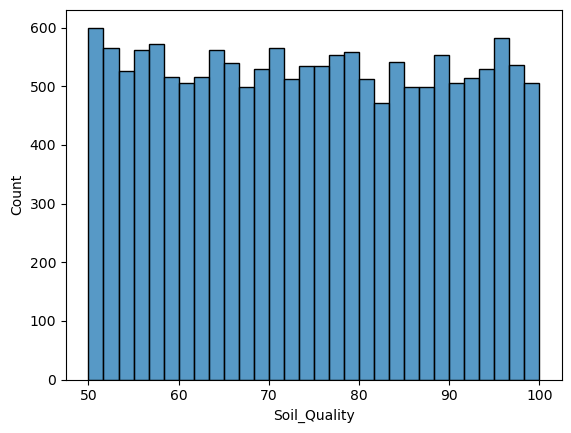

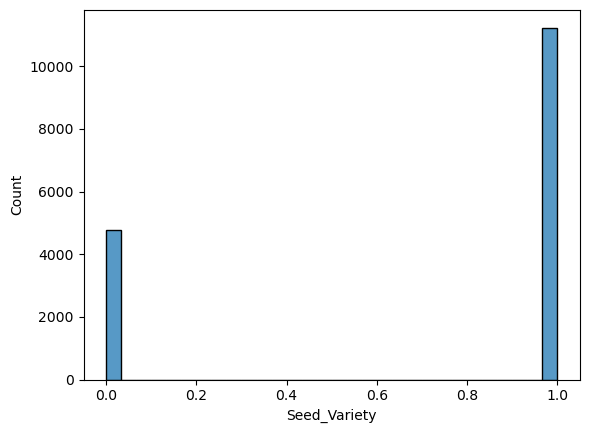

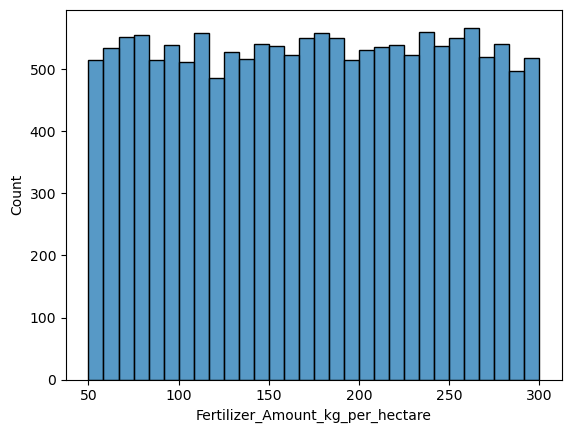

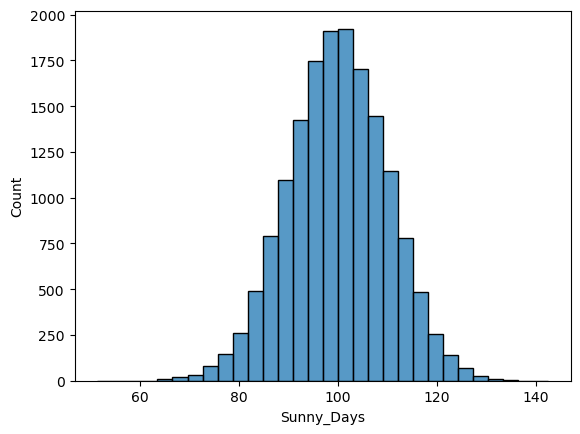

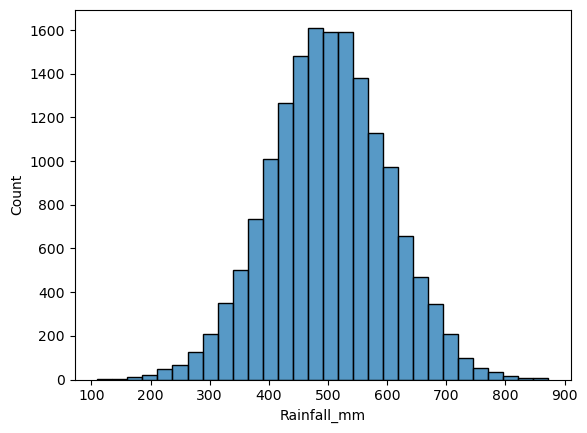

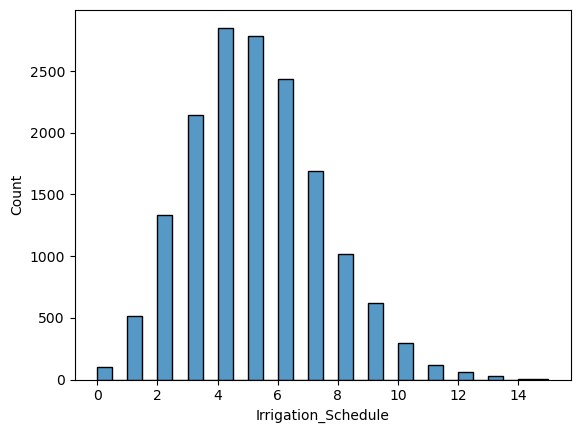

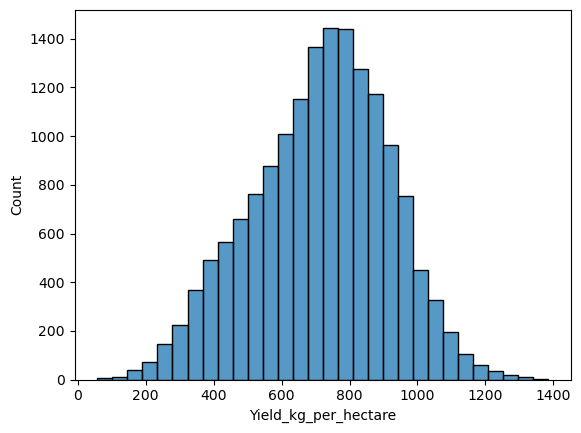

In [5]:
plot_num_vars(train_data, train_data.columns)

In [6]:
### features-target

X = train_data.drop(columns='Yield_kg_per_hectare',axis=1)
y = train_data['Yield_kg_per_hectare']

X.head()

,Soil_Quality,Seed_Variety,Fertilizer_Amount_kg_per_hectare,Sunny_Days,Rainfall_mm,Irrigation_Schedule
0,96.415657,1,147.853040,94.593926,444.267569,3
1,92.352626,0,281.565396,90.504644,517.585491,7
2,63.714785,1,137.864940,97.329340,420.310945,8
3,90.084256,1,100.946659,113.404828,547.817646,7
4,81.600341,1,223.088908,83.048176,434.726333,6


In [7]:
cat_var = [col for col in X.columns if X[col].dtype == 'O']
num_var = [col for col in X.columns if X[col].dtype != 'O']

num_pipeline = Pipeline(
    steps=[
        #('imputer', SimpleImputer(strategy="median")),
        ('scaler',StandardScaler())    
    ]
)

#cat_pipeline = Pipeline(
#    steps=[
#        ('imputer', SimpleImputer(strategy="most_frequent")),
#        ('encoder',OneHotEncoder())
#    ]
#)

preprocessor = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, num_var),
        #("cat_pipeline", cat_pipeline, cat_var)
    ]
)

In [8]:
X.shape

(16000, 6)

In [9]:
X = preprocessor.fit_transform(X)
X.shape

array([[ 1.49057429,  0.65153774, -0.37969108, -0.53443959, -0.5622634 ,
        -0.91195496],
       [ 1.21092146, -1.53483051,  1.4782081 , -0.9441751 ,  0.17048135,
         0.88207318],
       [-0.76018144,  0.65153774, -0.51847319, -0.26035816, -0.80168767,
         1.33058022],
       ...,
       [-0.50113104,  0.65153774, -0.76646408,  0.23855353,  0.13837295,
         1.33058022],
       [ 0.71702553,  0.65153774,  1.00970497,  1.50585106,  1.94393288,
         0.43356615],
       [ 0.9002053 , -1.53483051,  0.95925519, -0.16172404,  0.90214175,
         0.43356615]])

In [20]:
## train test split

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.25, random_state=0)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(12000, 6) (4000, 6) (12000,) (4000,)


In [22]:
### Evaluation function to give all metrics after model training

def evaluate_model(true_val, pred_val):
    mae = mean_absolute_error(true_val,pred_val)
    mse = mean_squared_error(true_val,pred_val)
    rmse = np.sqrt(mean_squared_error(true_val,pred_val))
    r2_square = r2_score(true_val,pred_val)
    return mse, rmse, r2_square

In [24]:
models ={
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random forest regressor" : RandomForestRegressor(),
    "XDBoostregressor": XGBRegressor(),
    "CatBoostregressor": CatBoostRegressor(verbose=False),
    "Adaboostregressor": AdaBoostRegressor()
}

model_list=[]
rmse_list=[]
r2_list=[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    #make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Evaluate train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_val_mae, model_val_rmse, model_val_r2 = evaluate_model(y_val, y_val_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance of training set")
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))
    
    print("--------------------------")

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_val_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_val_mae))    
    print("- R2 Score: {:.4f}".format(model_val_r2))
    r2_list.append(model_val_r2)
    rmse_list.append(model_val_rmse)

    print('='*35)
    print('\n')

Linear Regression
Model performance of training set
- Root Mean Squared Error: 49.8189
- Mean Absolute Error: 2481.9220
- R2 Score: 0.9388
--------------------------
Model performance for Test set
- Root Mean Squared Error: 50.7502
- Mean Absolute Error: 2575.5835
- R2 Score: 0.9384


Lasso
Model performance of training set
- Root Mean Squared Error: 49.8788
- Mean Absolute Error: 2487.8976
- R2 Score: 0.9387
--------------------------
Model performance for Test set
- Root Mean Squared Error: 50.8606
- Mean Absolute Error: 2586.8007
- R2 Score: 0.9382


Ridge
Model performance of training set
- Root Mean Squared Error: 49.8189
- Mean Absolute Error: 2481.9222
- R2 Score: 0.9388
--------------------------
Model performance for Test set
- Root Mean Squared Error: 50.7504
- Mean Absolute Error: 2575.6053
- R2 Score: 0.9384


KNN
Model performance of training set
- Root Mean Squared Error: 47.8277
- Mean Absolute Error: 2287.4858
- R2 Score: 0.9436
--------------------------
Model performa

In [25]:
pd.DataFrame(list(zip(model_list,rmse_list)),columns=['Model_Name','RMSE']).sort_values(by=["RMSE"],ascending=True)

,Model_Name,RMSE
0,Linear Regression,50.750207
2,Ridge,50.750421
1,Lasso,50.860600
7,CatBoostregressor,51.748841
5,Random forest regressor,55.811352
6,XDBoostregressor,55.971499
3,KNN,59.913266
8,Adaboostregressor,70.993721
4,Decision Tree,77.122552


In [28]:
model = LinearRegression()
model = model.fit(X,y)
test_data_copy = preprocessor.fit_transform(test_data)
y_pred = model.predict(test_data_copy)

In [36]:
models ={
        "Linear Regression": LinearRegression(),
        "KNN": KNeighborsRegressor(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random forest regressor" : RandomForestRegressor(),
        "XGBoostregressor": XGBRegressor(),
        "CatBoostregressor": CatBoostRegressor(verbose=False),
        "Adaboostregressor": AdaBoostRegressor()
        }

params={
    "Decision Tree": {
        'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        # 'splitter':['best','random'],
        # 'max_features':['sqrt','log2'],
    },
    "Random forest regressor":{
        # 'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
        # 'max_features':['sqrt','log2',None]
        'n_estimators': [8,16,32,64,128,256]
    },
    "Gradient Boosting":{
        # 'loss':['squared_error', 'huber', 'absolute_error', 'quantile'],
        'learning_rate':[.1,.01,.05,.001],
        'subsample':[0.6,0.7,0.75,0.8,0.85,0.9],
        # 'criterion':['squared_error', 'friedman_mse'],
        # 'max_features':['auto','sqrt','log2'],
        'n_estimators': [8,16,32,64,128,256]
    },
    "Linear Regression":{},
    "KNN":{
        'n_neighbors':[5,7,9,11]
    },
    "XGBoostregressor":{
        'learning_rate':[.1,.01,.05,.001],
        'n_estimators': [8,16,32,64,128,256]
    },
    "CatBoostregressor":{
        'depth': [6,8,10],
        'learning_rate': [0.01, 0.05, 0.1],
        'iterations': [30, 50, 100]
    },
    "Adaboostregressor":{
        'learning_rate':[.1,.01,0.5,.001],
        # 'loss':['linear','square','exponential'],
        'n_estimators': [8,16,32,64,128,256]
    }
}

def evaluate_models(X_train,y_train,X_test,y_test,models,param):
    report = {}
    for i in range(len(list(models))):
        model = list(models.values())[i]
        para=param[list(models.keys())[i]]
        
        gs = GridSearchCV(model,para,cv=3)
        gs.fit(X_train,y_train)
        model.set_params(**gs.best_params_)
        model.fit(X_train,y_train)
        #make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_val)
        train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred))
        test_model_score = np.sqrt(mean_squared_error(y_val,y_test_pred))
        report[list(models.keys())[i]] = test_model_score
    return report

model_report:dict=evaluate_models(X_train=X_train,y_train=y_train,
                                  X_test=X_val,y_test=y_val,
                                  models=models,param=params)

## To get best model score
best_model_score = max(sorted(model_report.values()))
print(best_model_score)
## to get best model name
best_model_name = list(model_report.keys())[
list(model_report.values()).index(best_model_score)
]

best_model = models[best_model_name]
best_model

76.30129883336392


DecisionTreeRegressor(criterion='poisson')

In [32]:
model = DecisionTreeRegressor(criterion='poisson')
model = model.fit(X,y)

test_data_copy = preprocessor.fit_transform(test_data)
y_pred = model.predict(test_data_copy)

In [34]:
y_pred

array([302.02444369, 917.97678769, 815.29321473, ..., 787.40579659,
       456.70889658, 256.36071161])